# Using DeepMReye, look at the median of 2 and 3 and comparing these within the cluster window (and other correlations)

As we have a lower sampling late, need to accommodate for misaligned timepoints. Cluster window buffered to 1s to account for this, no rounding.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
import numpy as np
from scipy.stats import pearsonr, spearmanr


os.chdir('/Users/alex/Documents/action_hippo/action_hippo/eyes/deepmreye')
file = 'all_trials_flat.csv'
lower_lim = 0.899 - 0.07145 #make 1s window, same number of datapoints in each subject following window usually used in deepMReye
upper_lim = 1.757 + 0.07145


In [2]:

# Load and clean data
df = pd.read_csv(file, index_col=None)
#df = df.drop('y', axis=1)
df['trial_type'] = pd.to_numeric(df['trial_type'], errors='coerce')
df['time_rel_acc'] = df['time_rel_acc'] - 0.5
df = df[(df['time_rel_acc'] <= upper_lim) & (df['time_rel_acc'] >= lower_lim)].copy() # window of 10 timepoints centred around cluster
# Step 1: Median x per trial
df_trial_medians = df.groupby(['subject', 'trial_id', 'trial_type'])[['x']].median().reset_index()
# Step 2: Count datapoints per trial
trial_counts = df.groupby(['subject', 'trial_id', 'trial_type']).size().reset_index(name='n_timepoints')
# Step 3: Compute average number of timepoints per trial per subject/trial_type
mean_counts = trial_counts.groupby(['subject', 'trial_type'])['n_timepoints'].median().reset_index()
num_timepoints = mean_counts['n_timepoints'].tolist()
# Step 4: Median x per subject/trial_type
df_subject_means = df_trial_medians.groupby(['subject', 'trial_type'])[['x']].median().reset_index()
# Step 5: Pivot to wide format
df_wide = df_subject_means.pivot(index='subject', columns='trial_type', values='x')
# Step 6: Keep only complete cases
df_wide = df_wide.dropna(subset=[2, 3]).rename(columns={2: 'x_type2', 3: 'x_type3'})
# Step 7: Paired one-sided t-test
tstat, pval_one_sided = ttest_rel(df_wide['x_type2'], df_wide['x_type3'], alternative='greater')

print(f"\n✅ One-sided paired t-test p-value (H1: median x_type2 > x_type3): {pval_one_sided:.5f}")
print(f"📊 Average number of timepoints per trial (per subject/trial_type): {num_timepoints}")


✅ One-sided paired t-test p-value (H1: median x_type2 > x_type3): 0.02367
📊 Average number of timepoints per trial (per subject/trial_type): [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0,

In [3]:
# Assuming df is your current DataFrame with subject as index
df_wide['x_diff'] = df_wide['x_type2'] - df_wide['x_type3']
# Keep only the subject index and x_diff column
df_result_diff = df_wide[['x_diff']].reset_index()
# load in df from rdm_correlations.csv
df_rdm = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/deepmreye/rdm_correlations_partial_normed.csv')
# note that this includes normed RDM values for the comparison between individual cells and gaze effect
df_rdm = df_rdm.loc[df_rdm['region']=='Entorhinal-right'].copy()
df_rdm = df_rdm.loc[df_rdm['model']=='affordance'].copy()

# Convert to same subject ID format as df_rdm
df_result_diff['sub'] = df_result_diff['subject'].apply(lambda x: f"sub-{x:02d}")
# Step 2: Merge into df_rdm on 'sub'
df_rdm_merged = df_rdm.merge(df_result_diff[['sub', 'x_diff']], on='sub', how='left')

# Add in ET results fropm day 1
df_day_one = pd.read_csv('/Users/alex/Documents/action_hippo/action_hippo/eyes/change_x_median.csv')

# Then merge change_x into that
df_rdm_merged = df_rdm_merged.merge(df_day_one[['sub', 'change_x']], on='sub', how='left')
len(df_rdm_merged)

57

In [4]:
from scipy.stats import pearsonr

# Drop rows with missing values in relevant columns
#df_corr = df_rdm_merged.dropna(subset=['x_diff', 'change_x', 'performance', 'correlation', '32_rdm_value_norm', '32_rdm_value'])
df_corr = df_rdm_merged.copy()


# === Correlations using Day 2 data (x_diff) ===
r_perf, p_perf = pearsonr(df_corr['x_diff'], df_corr['performance'])
r_rdm, p_rdm = pearsonr(df_corr['x_diff'], df_corr['correlation'])
r_32norm, p_32norm = pearsonr(df_corr['x_diff'], df_corr['32_rdm_value_norm'])
# === Print results ===
print("=== 📈 Correlations using Day 2 data (x_diff) ===")
print(f"🔸 x_diff vs performance:               r = {r_perf:.3f}, p = {p_perf:.4f}")
print(f"🔸 x_diff vs neural RDM correlation:    r = {r_rdm:.3f}, p = {p_rdm:.4f}")
print(f"🔸 x_diff vs 3-2 RDM norm:              r = {r_32norm:.3f}, p = {p_32norm:.4f}")

=== 📈 Correlations using Day 2 data (x_diff) ===
🔸 x_diff vs performance:               r = 0.194, p = 0.1482
🔸 x_diff vs neural RDM correlation:    r = 0.231, p = 0.0844
🔸 x_diff vs 3-2 RDM norm:              r = 0.263, p = 0.0484


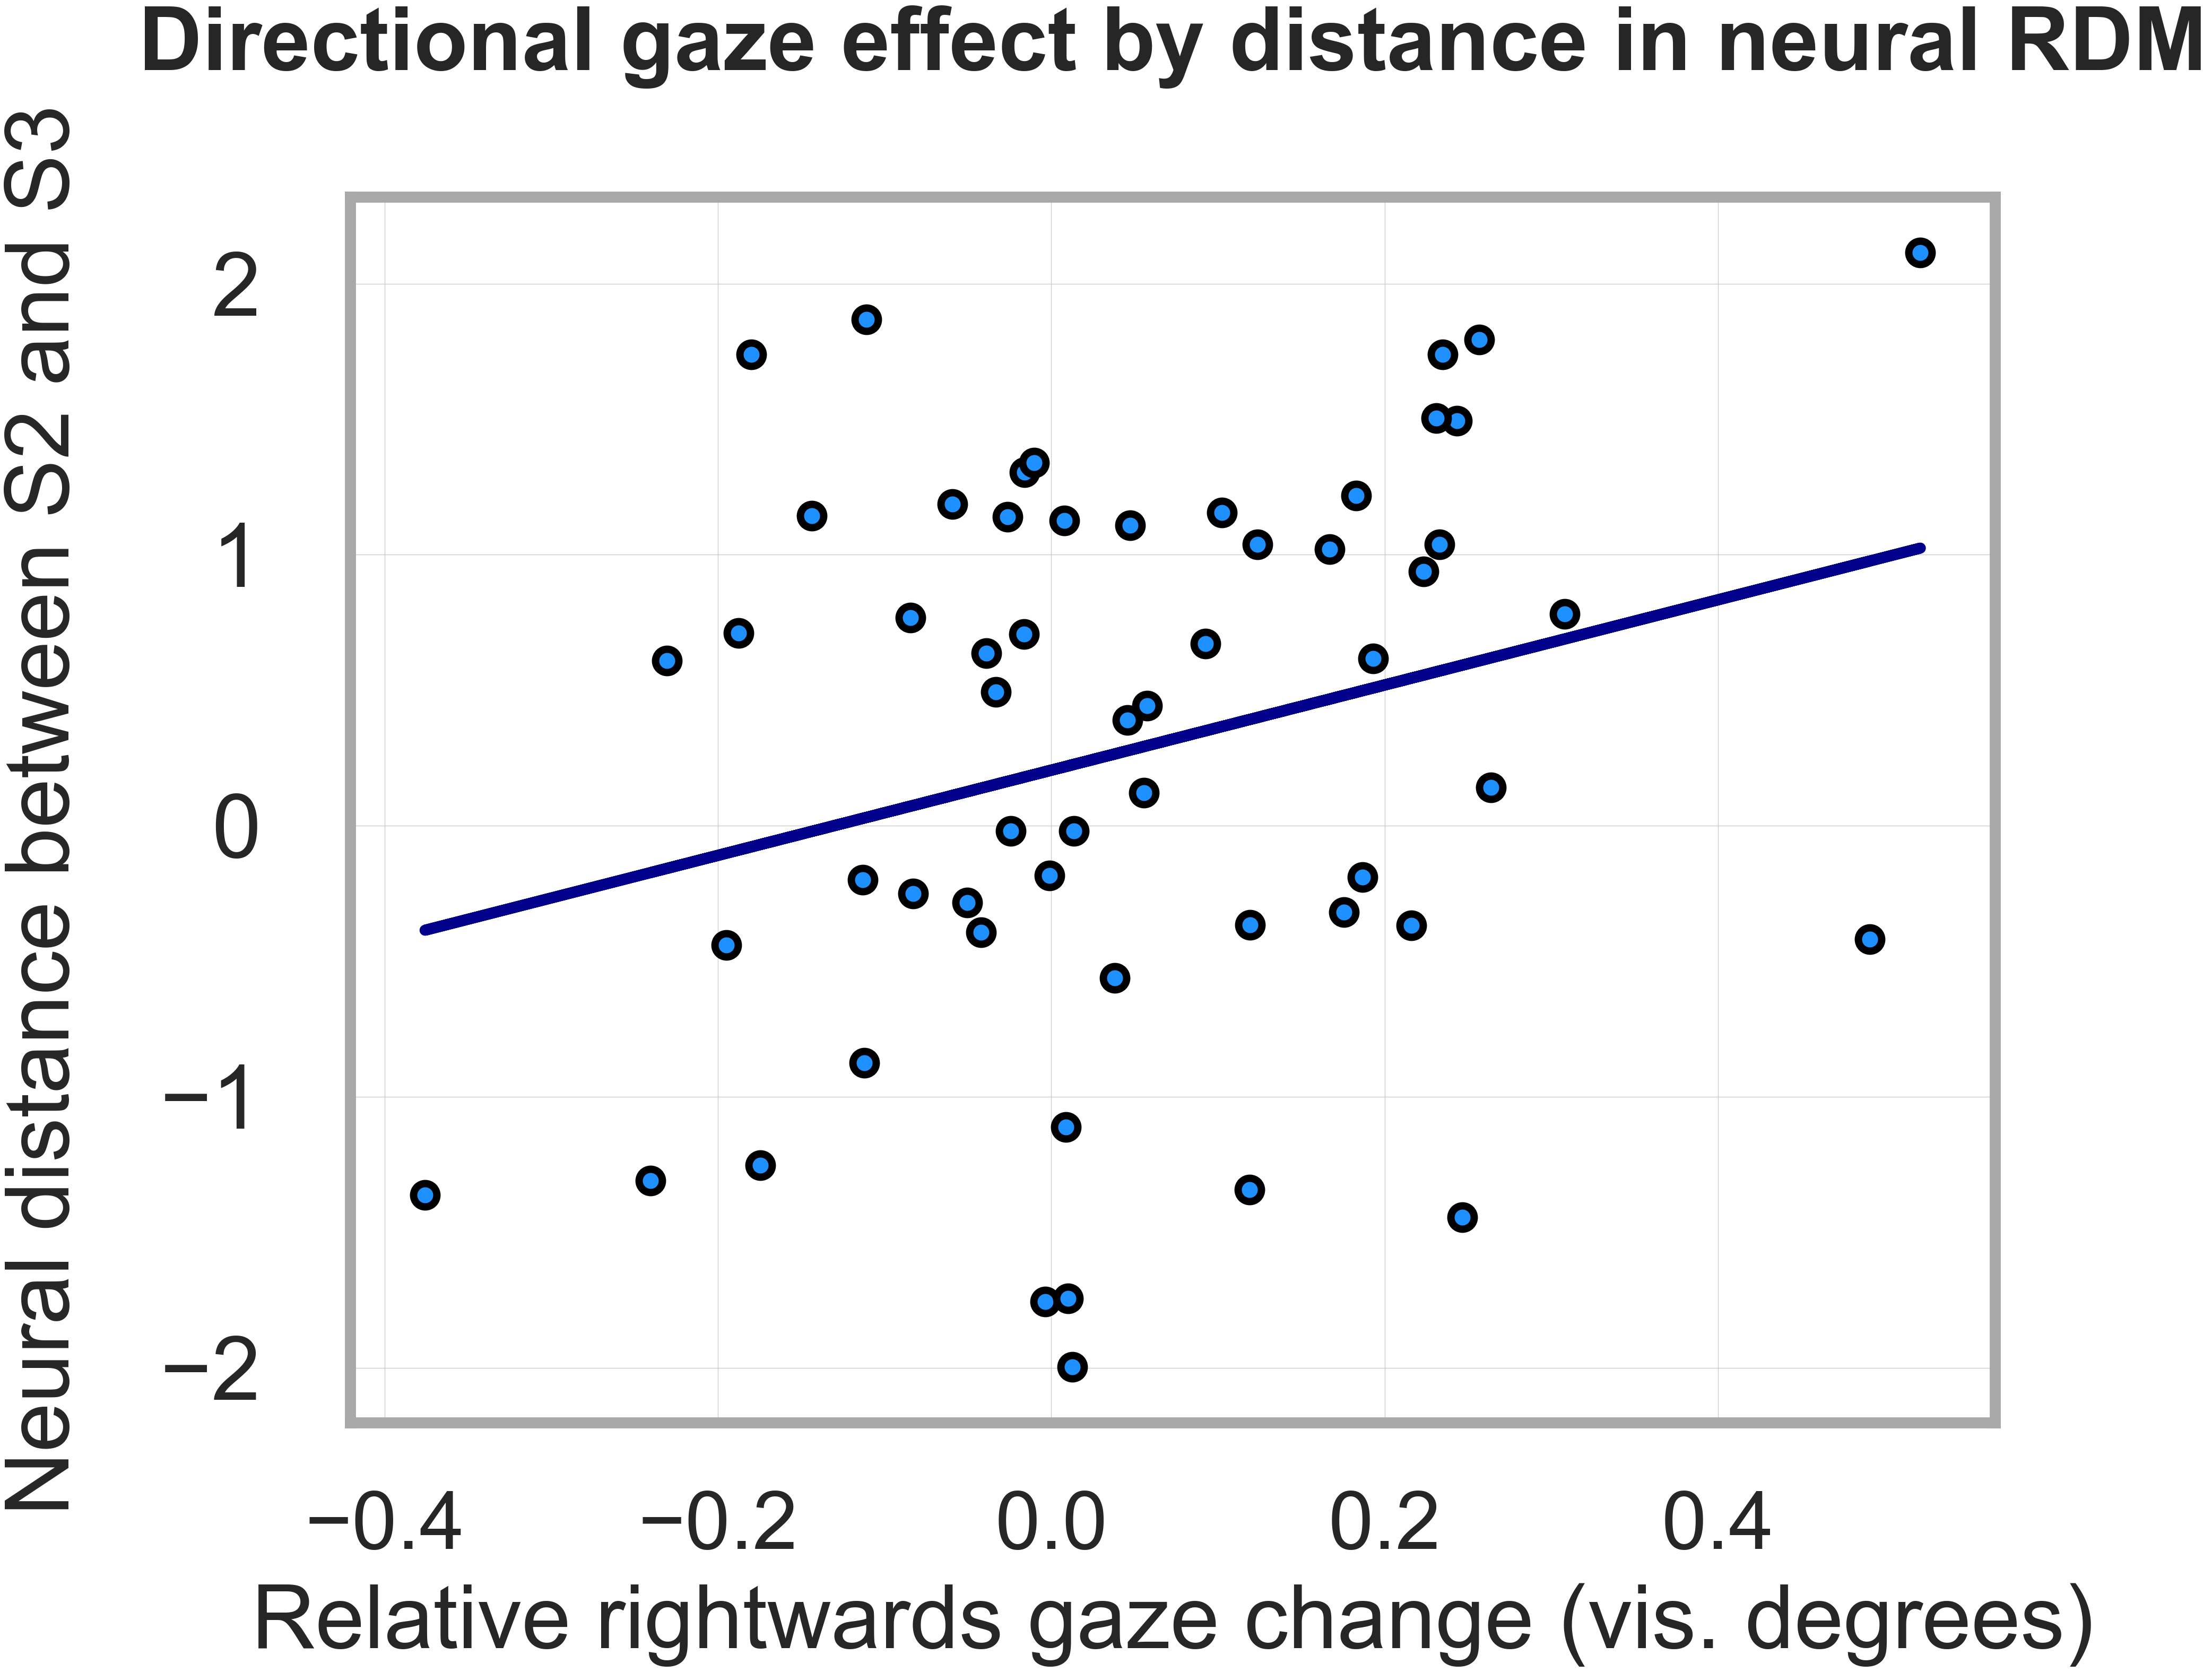

In [6]:
# plot correlation between change_x and correlation


# add regression line
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt


# make this plot nicer

# set sns style as wgrid
sns.set(style='whitegrid')
# set plot size as 10*20
plt.figure(figsize=(40, 30))
# add y label and x label

# add a title, size 30 and not right next to plot, Change in x position vs performance during eyetracking

# scatterplot of change_x over time
ax = sns.scatterplot(x='x_diff', y='32_rdm_value_norm', data=df_corr, color='darkblue', s=1000)

x = df_corr['x_diff']
y = df_corr['32_rdm_value_norm']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
line = slope*x+intercept
plt.plot(x, line, 'r', label='y={:.2f}x+{:.2f}'.format(slope,intercept), linewidth=15)
# make line dark grey
plt.gca().lines[0].set_color('darkblue')
# make points dodgerblue with darkgrey edge
plt.gca().collections[0].set_color('dodgerblue')
plt.gca().collections[0].set_edgecolor('black')
# make points bigger
# make edges thicker
plt.gca().collections[0].set_linewidth(10)
# make titles and labels bigger
# set sns style as wgrid
sns.set(style='whitegrid')
# make y axis labels bigger
plt.yticks(fontsize=120, x=-0.05)
# change x axis label to 'Trial group'
plt.xlabel('Relative rightwards gaze change (vis. degrees)', fontsize=120, labelpad=25)
# make x axis labels bigger
plt.xticks(fontsize=110, y=-0.05)
# make y axis labels bigger
plt.yticks(fontsize=120)
# change y axis label to 'Performance'
plt.ylabel('Neural distance between S2 and S3', fontsize=120, labelpad=100)
# add title
plt.title('Directional gaze effect by distance in neural RDM', fontsize=120, y=1.1, fontweight='bold')

# draw a dark box around the plot
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(15)
    # make it dark grey
    ax.spines[axis].set_color('darkgrey')
# add dots at y=1.1 for the interval of significant clusters, which is x=1181 to 1579

plt.show()

## Make some plots

In [8]:
df_plotting = pd.read_csv(file, index_col=None)
#df = df.drop('y', axis=1)
df_plotting['trial_type'] = pd.to_numeric(df_plotting['trial_type'], errors='coerce')
df_plotting['time_rel_acc'] = df_plotting['time_rel_acc'] - 0.5

df_plotting.head()

,subject,run,trial_type,trial_id,time,time_rel,time_rel_acc,x,y
0,31,run-05,3,3105001,12.5,-0.5,-0.426293,1.422090,2.950964
1,31,run-05,3,3105001,12.6,-0.4,-0.326293,1.047589,3.293236
2,31,run-05,3,3105001,12.7,-0.3,-0.226293,1.091275,2.861034
3,31,run-05,3,3105001,12.8,-0.2,-0.126293,1.072374,3.041230
4,31,run-05,3,3105001,12.9,-0.1,-0.026293,0.976283,2.461257


/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alex/opt/anaconda3/envs/mne-multimatch/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


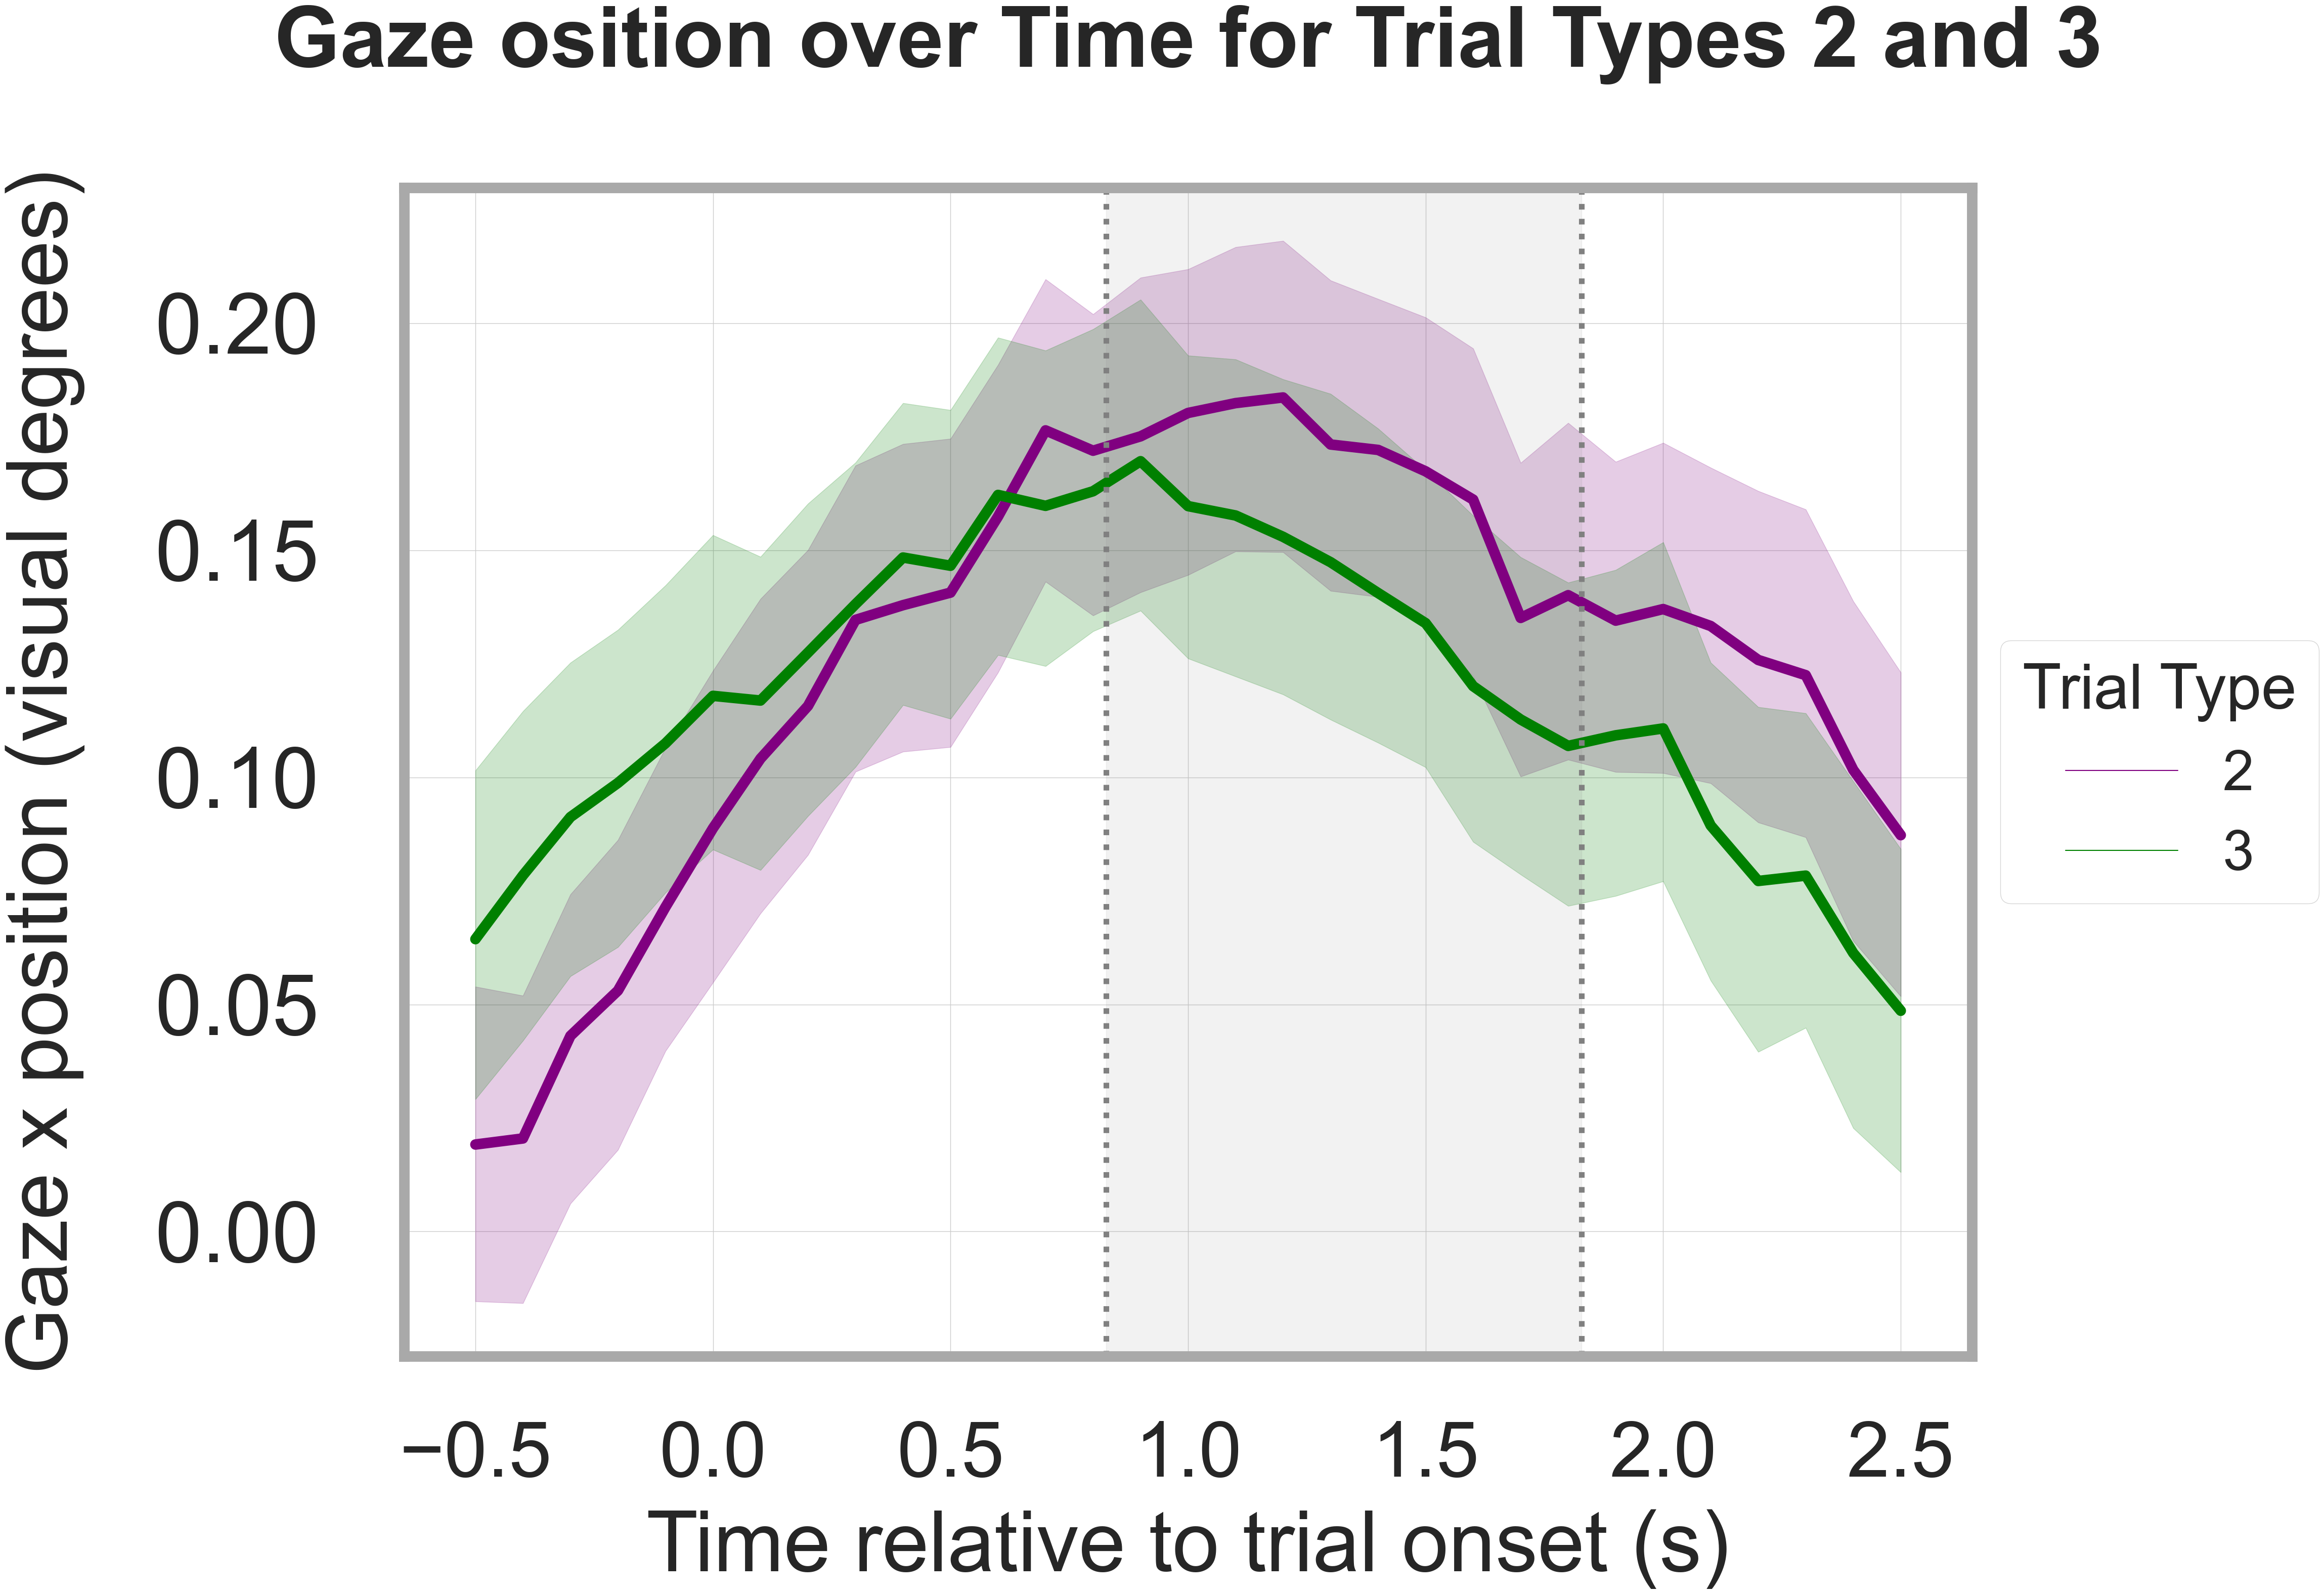

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for trial_type 2 and 3
df_filtered = df_plotting[df_plotting['trial_type'].isin([2, 3])]

# Set Seaborn style
sns.set(style='whitegrid')
plt.figure(figsize=(40, 30))

# Custom color palette
custom_palette = {2: 'purple', 3: 'green'}

# Plot lines
ax = sns.lineplot(
    data=df_filtered,
    x='time_rel',
    y='x',
    hue='trial_type',
    palette=custom_palette,
    linewidth=15
)

# Labels and title
plt.xlabel('Time relative to trial onset (s)', fontsize=120, labelpad=25)
plt.ylabel('Gaze x position (visual degrees)', fontsize=120, labelpad=100)
plt.title('Gaze osition over Time for Trial Types 2 and 3', fontsize=120, y=1.1, fontweight='bold')

# Ticks
plt.xticks(fontsize=110, y=-0.05)
plt.yticks(fontsize=120, x=-0.05)

# Legend outside
plt.legend(
    title='Trial Type',
    fontsize=80,
    title_fontsize=90,
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

# Define region boundaries
x_start = 0.899 - 0.07145  # 0.82755
x_end = 1.757 + 0.07145    # 1.82845

# Add shaded region
plt.axvspan(
    x_start,
    x_end,
    color='grey',
    alpha=0.1  # very faint
)

# Add vertical dotted lines
plt.axvline(x=x_start, color='grey', linestyle=':', linewidth=8)
plt.axvline(x=x_end, color='grey', linestyle=':', linewidth=8)

# Dark grey plot borders
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(15)
    ax.spines[axis].set_color('darkgrey')

plt.show()


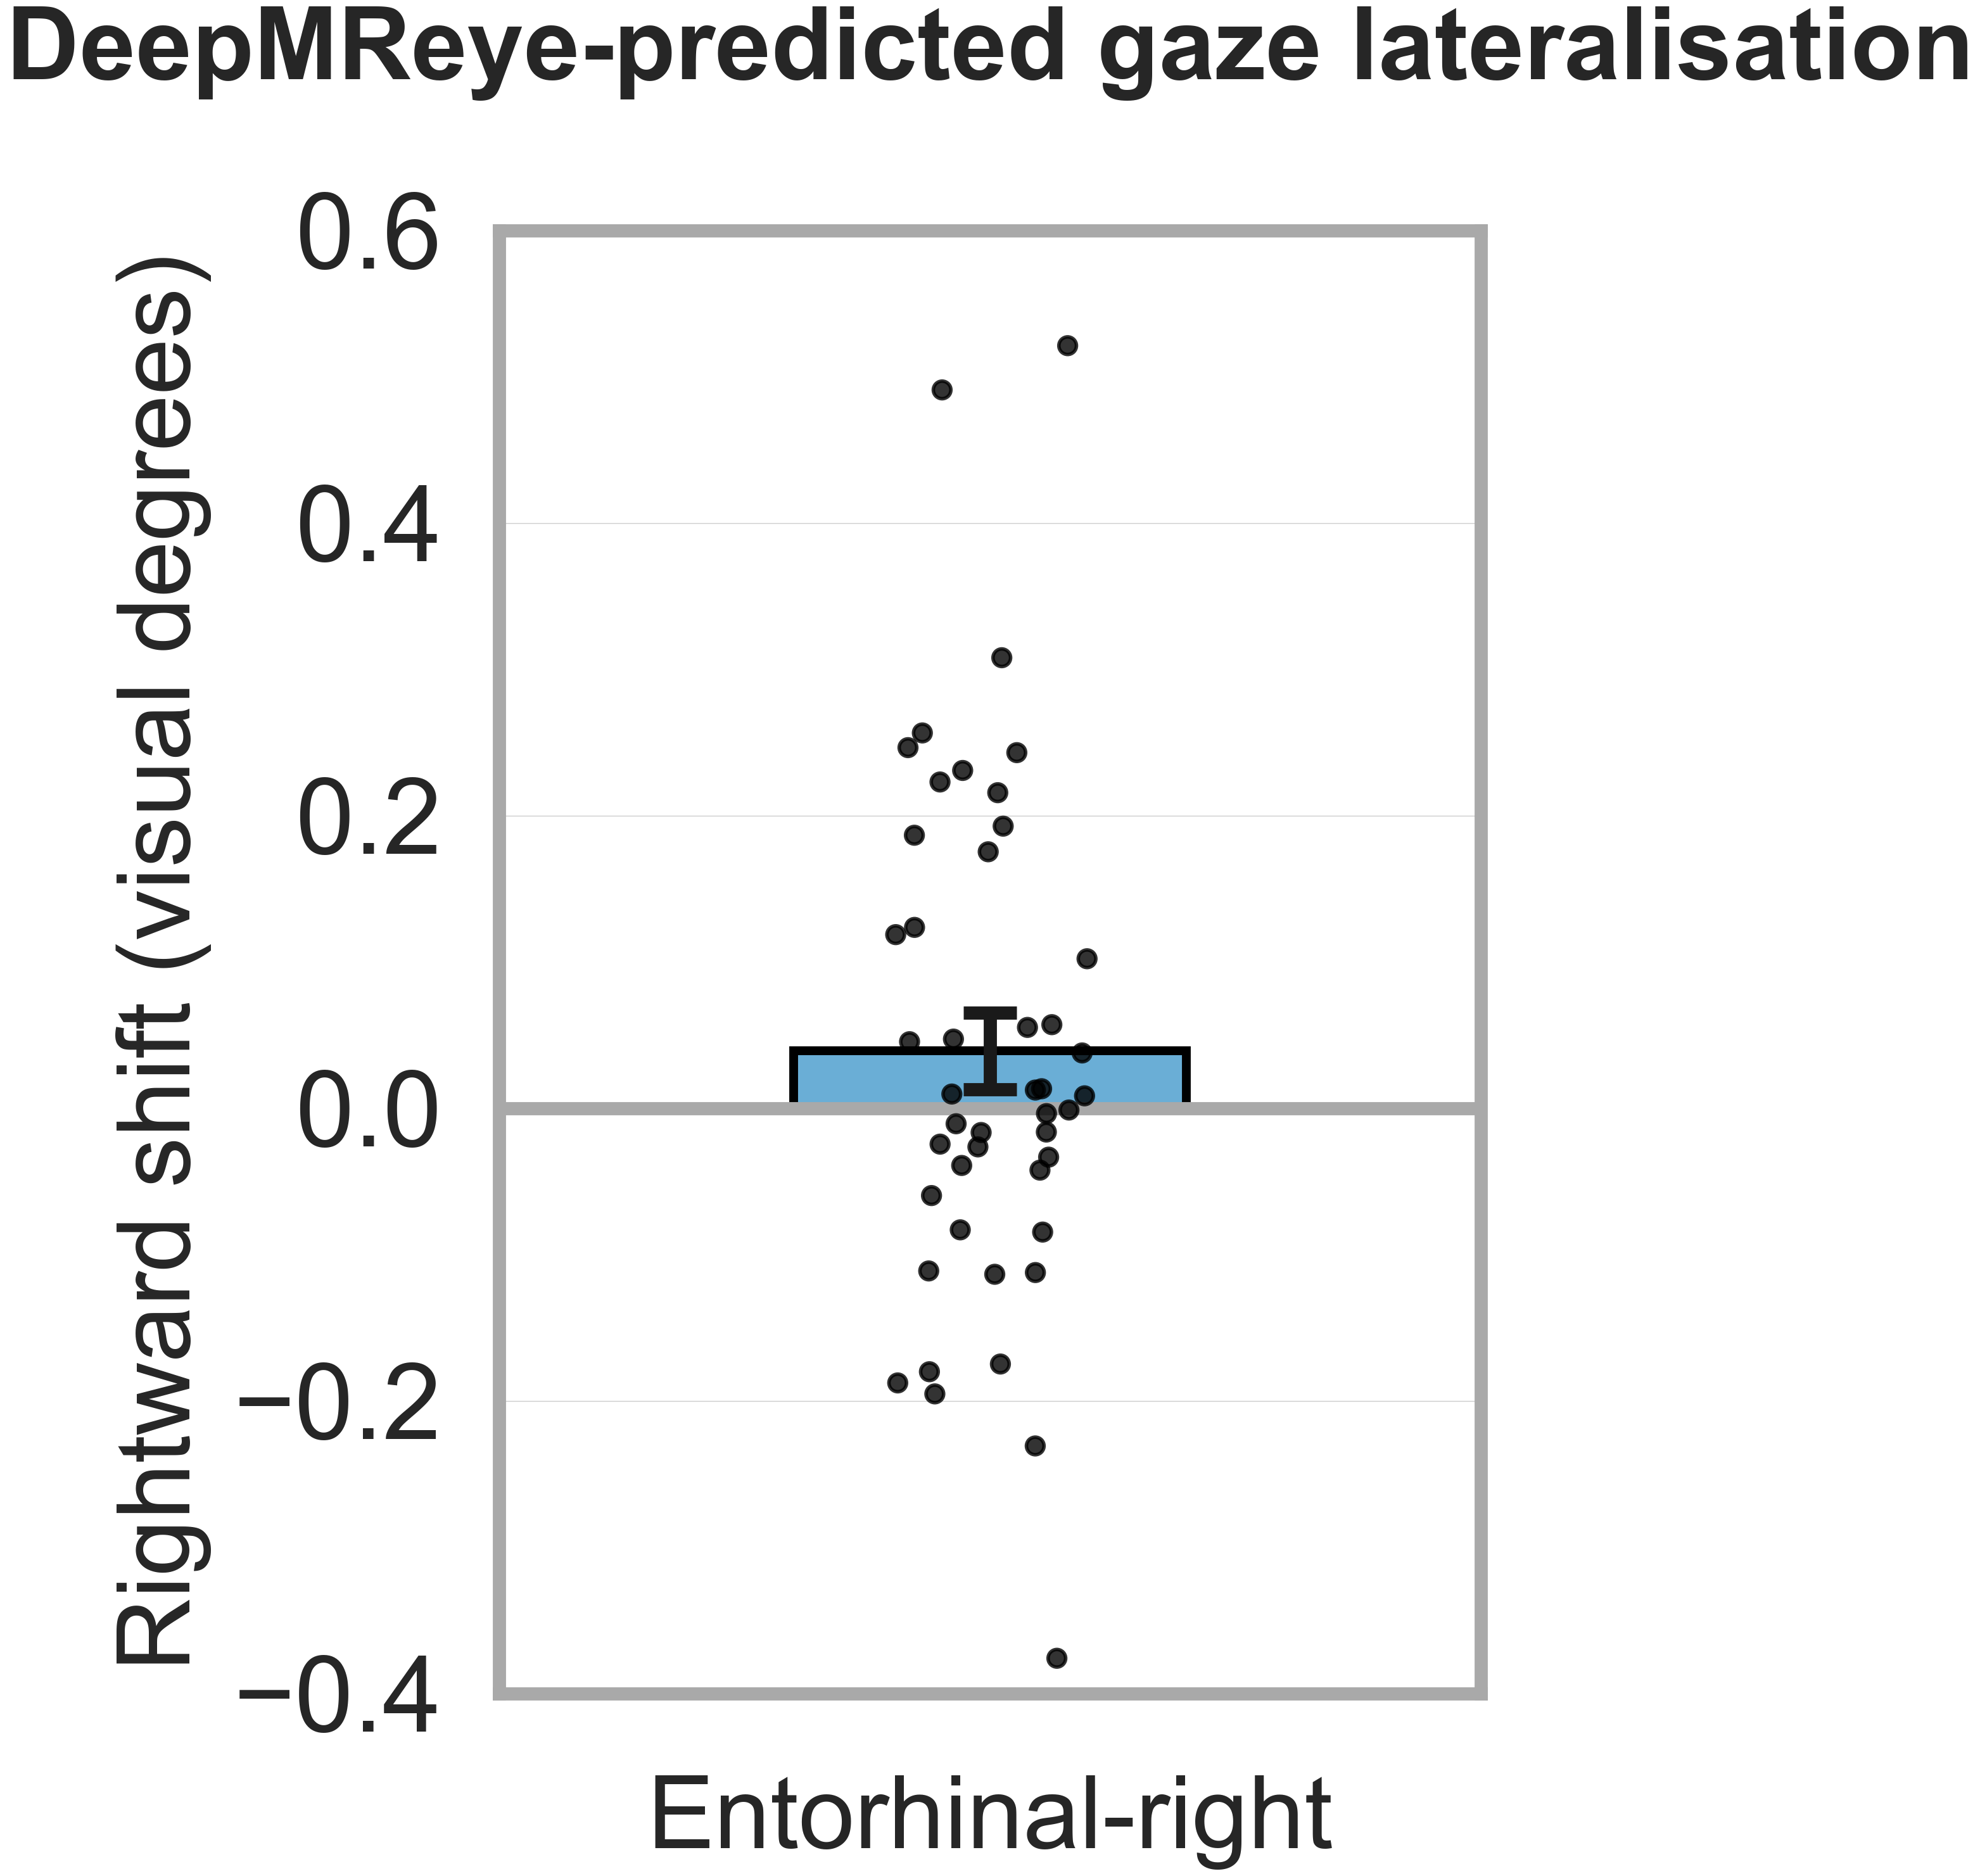

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Compute mean and SEM
grouped = df_corr.groupby('region')['x_diff']
summary_df = grouped.agg(['mean', 'sem']).reset_index()

# Step 2: Set up figure
f, ax = plt.subplots(figsize=(20, 30))
sns.set_palette("Blues")

# Step 3: Draw bars manually with matplotlib
x = np.arange(len(summary_df))
bar_width = 0.4

bars = ax.bar(
    x,
    summary_df['mean'],
    yerr=summary_df['sem'],
    width=bar_width,
    color=sns.color_palette("Blues", len(summary_df)),
    edgecolor='black',
    linewidth=10,
    capsize=30,            # <== CAP size (in points)
    error_kw={
        'elinewidth': 15,  # <== SEM line thickness
        'capthick': 15     # <== cap line thickness
    }
)

# Step 4: Overlay individual points with Seaborn
sns.stripplot(
    x='region',
    y='x_diff',
    data=df_corr,
    ax=ax,
    size=20,
    jitter=True,
    alpha=0.8,
    edgecolor='black',
    linewidth=4,
    color='black'
)

# Step 5: Axes cleanup
plt.xticks(x, summary_df['region'], fontsize=115, y=-0.05)
plt.yticks(fontsize=120, x=-0.05)
plt.ylim(-0.4, 0.6)

plt.xlabel('', fontsize=100, labelpad=25)
plt.ylabel('Rightward shift (visual degrees)', fontsize=115, labelpad=25)
plt.title('DeepMReye-predicted gaze lateralisation', fontsize=115, y=1.1, fontweight='bold')
plt.axhline(0, color='darkgrey', linewidth=15)

# Dark border
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(15)
    ax.spines[side].set_color('darkgrey')

plt.show()
